<a href="https://colab.research.google.com/github/Nishchayk/semantic-warehouse-sim-and-ros2-robot/blob/main/Task1_Warehouse_PyBullet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pybullet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 10.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pybullet: filename=pybullet-3.2.7-cp313-cp313-linux_x86_64.whl size=99120544 sha256=3f9d8a9a854aa90fa41900aa94fe24099f77cb00321bdb460d1a556f0ef68fdb
  Stored in directory: /root/.cache/pip/wheels/8a/f0/6a/3f626b4ee04f8ec61e40021b095adf5359f9bd426065a368ac
Successfully built pybullet


In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pybullet as p
import pybullet_data


p.connect(p.DIRECT)
p.resetSimulation()
p.setAdditionalSearchPath(pybullet_data.getDataPath())
p.setGravity(0,0,-9.8)
p.setRealTimeSimulation(0)

In [ ]:
floor_urdf = """<?xml version="1.0"?>
<robot name="warehouse_floor">
  <!-- Warehouse floor slab covering the entire layout.
       Footprint: 10 m (x) x 7 m (y), centred at the origin, so it spans
         x: -5.0 .. 5.0   (charging station at -4.3, inbound zone/packages up to ~4.5)
         y: -3.5 .. 3.5   (conveyor at -2.5, inbound zone at 2.0, charging station at 1.8)
       Fixed: the old box had zero height ("2 2 0"), which is an invalid collision shape.
       Now 0.02 m thick. The slab is shifted down so its top face sits at z = 0.005,
       just above PyBullet's built-in plane (avoids flickering/z-fighting) while the
       0.02 m zone pads and everything else still sit visibly on top of it. -->
  <material name="floor_concrete">
    <color rgba="0.82 0.82 0.80 1.0"/>
  </material>

  <link name="base_link">
    <inertial>
      <mass value="50.0"/>
      <origin xyz="0 0 0"/>
      <inertia ixx="10" ixy="0" ixz="0" iyy="10" iyz="0" izz="10"/>
    </inertial>
    <visual>
      <origin xyz="0 0 -0.005" rpy="0 0 0"/>
      <geometry><box size="10 7 0.02"/></geometry>
      <material name="floor_concrete"/>
    </visual>
    <collision>
      <origin xyz="0 0 -0.005" rpy="0 0 0"/>
      <geometry><box size="10 7 0.02"/></geometry>
    </collision>
  </link>
</robot>
"""

In [ ]:
shelf_urdf = """<?xml version="1.0"?>
<robot name="long_shelf">
  <!-- Role: storage / target. The tall blue bar in your layout. -->
  <material name="shelf_blue">
    <color rgba="0.05 0.3 0.45 1.0"/>
  </material>

  <link name="base_link"/>

  <link name="shelf_body">
    <inertial>
      <origin xyz="0 0 0.5" rpy="0 0 0"/>
      <mass value="8.0"/>
      <inertia ixx="0.3" ixy="0" ixz="0" iyy="0.3" iyz="0" izz="0.2"/>
    </inertial>
    <visual>
      <origin xyz="0 0 0.5" rpy="0 0 0"/>
      <geometry>
        <!-- length(x) x depth(y) x height(z) -->
        <box size="0.35 1.8 1.0"/>
      </geometry>
      <material name="shelf_blue"/>
    </visual>
    <collision>
      <origin xyz="0 0 0.5" rpy="0 0 0"/>
      <geometry>
        <box size="0.35 1.8 1.0"/>
      </geometry>
    </collision>
  </link>

  <joint name="base_joint" type="fixed">
    <parent link="base_link"/>
    <child link="shelf_body"/>
    <origin xyz="0 0 0" rpy="0 0 0"/>
  </joint>
</robot>
"""

In [ ]:
zone_urdf = """<?xml version="1.0"?>
<robot name="restricted_zone">
  <!-- Role: no-entry / keep-out zone. Robot must not enter this footprint,
       so the robot's path planner should treat it as an obstacle region.
       Modeled as a thin, semi-transparent floor pad (with collision, so a
       naive planner or physics check will register it as blocked space)
       sized larger than the shelf it wraps, matching the pink hatched
       border in your layout. -->
  <material name="restricted_pink">
    <color rgba="1.0 0.4 0.4 0.45"/>
  </material>

  <link name="base_link">
    <inertial>
      <mass value="0.5"/>
      <origin xyz="0 0 0"/>
      <inertia ixx="0.01" ixy="0" ixz="0" iyy="0.01" iyz="0" izz="0.01"/>
    </inertial>
    <visual>
      <origin xyz="0 0 0.01" rpy="0 0 0"/>
      <geometry>
        <!-- Wraps around the 0.35 x 1.8 shelf footprint with a margin -->
        <box size="0.65 2.1 0.02"/>
      </geometry>
      <material name="restricted_pink"/>
    </visual>
    <collision>
      <origin xyz="0 0 0.01" rpy="0 0 0"/>
      <geometry>
        <box size="0.65 2.1 0.02"/>
      </geometry>
    </collision>
  </link>
</robot>
"""

In [ ]:
inbound_urdf = """<?xml version="1.0"?>
<robot name="inbound_zone">
  <!-- Role: inbound. Floor marker where incoming items arrive before being
       loaded onto a shelf. Visual-only pad (no collision) so the robot can
       drive over/into it freely, matching the light green square top-right
       of your layout. -->
  <material name="inbound_green">
    <color rgba="0.75 0.95 0.75 1.0"/>
  </material>

  <link name="base_link">
    <inertial>
      <mass value="0.2"/>
      <origin xyz="0 0 0"/>
      <inertia ixx="0.005" ixy="0" ixz="0" iyy="0.005" iyz="0" izz="0.005"/>
    </inertial>
    <visual>
      <origin xyz="0 0 0.01" rpy="0 0 0"/>
      <geometry>
        <box size="0.5 0.4 0.02"/>
      </geometry>
      <material name="inbound_green"/>
    </visual>
    <!-- No collision: this is a marked zone, not a physical obstacle -->
  </link>
</robot>
"""

In [ ]:
conveyor_urdf = """<?xml version="1.0"?>
<robot name="conveyor_belt">
  <!-- Role: conveyor. Long low grey strip where objects are dropped for
       transport, matching the horizontal grey bar along the bottom of
       your layout. Has collision since it's a real raised physical object
       the robot must route around (or dock alongside). -->
  <material name="conveyor_grey">
    <color rgba="0.5 0.5 0.5 1.0"/>
  </material>

  <link name="base_link">
    <inertial>
      <origin xyz="0 0 0.05" rpy="0 0 0"/>
      <mass value="6.0"/>
      <inertia ixx="0.05" ixy="0" ixz="0" iyy="0.5" iyz="0" izz="0.5"/>
    </inertial>
    <visual>
      <origin xyz="0 0 0.05" rpy="0 0 0"/>
      <geometry>
        <box size="6.8 0.35 0.1"/>
      </geometry>
      <material name="conveyor_grey"/>
    </visual>
    <collision>
      <origin xyz="0 0 0.05" rpy="0 0 0"/>
      <geometry>
        <box size="6.8 0.35 0.1"/>
      </geometry>
    </collision>
  </link>
</robot>
"""

In [ ]:
package_urdf = """<?xml version="1.0"?>
<robot name="outbound_package">
  <!-- Role: outbound. Small packed package block ready to leave the
       warehouse, matching the dark red squares bottom-right of your
       layout. Load this file multiple times (different positions) to get
       several package instances, as in the image. -->
  <material name="package_red">
    <color rgba="0.75 0.05 0.05 1.0"/>
  </material>

  <link name="base_link">
    <inertial>
      <origin xyz="0 0 0.075" rpy="0 0 0"/>
      <mass value="1.0"/>
      <inertia ixx="0.01" ixy="0" ixz="0" iyy="0.01" iyz="0" izz="0.01"/>
    </inertial>
    <visual>
      <origin xyz="0 0 0.075" rpy="0 0 0"/>
      <geometry>
        <box size="0.15 0.15 0.15"/>
      </geometry>
      <material name="package_red"/>
    </visual>
    <collision>
      <origin xyz="0 0 0.075" rpy="0 0 0"/>
      <geometry>
        <box size="0.15 0.15 0.15"/>
      </geometry>
    </collision>
  </link>
</robot>
"""

In [ ]:
station_urdf = """<?xml version="1.0"?>
<robot name="charging_station">

  <!-- Materials -->
  <material name="station_dark">
    <color rgba="0.15 0.15 0.15 1.0"/>
  </material>

  <material name="station_accent">
    <color rgba="0.0 0.6 0.8 1.0"/>
  </material>

  <material name="copper_contacts">
    <color rgba="0.85 0.53 0.10 1.0"/>
  </material>

  <!-- Main Base Plate (Ground fixture) -->
  <link name="charging_station_base">
    <inertial>
      <mass value="10.0"/>
      <origin xyz="0 0 0.01"/>
      <inertia ixx="0.1" ixy="0" ixz="0" iyy="0.1" iyz="0" izz="0.2"/>
    </inertial>
    <visual>
      <origin xyz="0 0 0.01" rpy="0 0 0"/>
      <geometry>
        <box size="0.50 0.46 0.02"/>
      </geometry>
      <material name="station_dark"/>
    </visual>
    <collision>
      <origin xyz="0 0 0.01" rpy="0 0 0"/>
      <geometry>
        <box size="0.50 0.46 0.02"/>
      </geometry>
    </collision>
  </link>

  <!-- Back Tower Wall -->
  <link name="back_tower">
    <inertial>
      <mass value="5.0"/>
      <origin xyz="0 0 0"/>
      <inertia ixx="0.05" ixy="0" ixz="0" iyy="0.05" iyz="0" izz="0.05"/>
    </inertial>
    <visual>
      <geometry>
        <box size="0.06 0.46 0.30"/>
      </geometry>
      <material name="station_dark"/>
    </visual>
    <collision>
      <geometry>
        <box size="0.06 0.46 0.30"/>
      </geometry>
    </collision>
  </link>

  <joint name="back_tower_joint" type="fixed">
    <parent link="charging_station_base"/>
    <child link="back_tower"/>
    <origin xyz="0.22 0 0.16" rpy="0 0 0"/>
  </joint>

  <!-- Left Guide Rail -->
  <link name="left_guide_rail">
    <visual>
      <geometry>
        <box size="0.38 0.03 0.08"/>
      </geometry>
      <material name="station_accent"/>
    </visual>
    <collision>
      <geometry>
        <box size="0.38 0.03 0.08"/>
      </geometry>
    </collision>
  </link>

  <joint name="left_guide_rail_joint" type="fixed">
    <parent link="charging_station_base"/>
    <child link="left_guide_rail"/>
    <origin xyz="0 0.20 0.06" rpy="0 0 0"/>
  </joint>

  <!-- Right Guide Rail -->
  <link name="right_guide_rail">
    <visual>
      <geometry>
        <box size="0.38 0.03 0.08"/>
      </geometry>
      <material name="station_accent"/>
    </visual>
    <collision>
      <geometry>
        <box size="0.38 0.03 0.08"/>
      </geometry>
    </collision>
  </link>

  <joint name="right_guide_rail_joint" type="fixed">
    <parent link="charging_station_base"/>
    <child link="right_guide_rail"/>
    <origin xyz="0 -0.20 0.06" rpy="0 0 0"/>
  </joint>

  <!-- Charging Contact Pins (Positive and Negative) -->
  <link name="contact_pin_positive">
    <visual>
      <geometry>
        <cylinder radius="0.01" length="0.03"/>
      </geometry>
      <material name="copper_contacts"/>
    </visual>
    <collision>
      <geometry>
        <cylinder radius="0.01" length="0.03"/>
      </geometry>
    </collision>
  </link>

  <joint name="contact_positive_joint" type="fixed">
    <parent link="back_tower"/>
    <child link="contact_pin_positive"/>
    <origin xyz="-0.03 0.06 -0.05" rpy="0 1.5708 0"/>
  </joint>

  <link name="contact_pin_negative">
    <visual>
      <geometry>
        <cylinder radius="0.01" length="0.03"/>
      </geometry>
      <material name="copper_contacts"/>
    </visual>
    <collision>
      <geometry>
        <cylinder radius="0.01" length="0.03"/>
      </geometry>
    </collision>
  </link>

  <joint name="contact_negative_joint" type="fixed">
    <parent link="back_tower"/>
    <child link="contact_pin_negative"/>
    <origin xyz="-0.03 -0.06 -0.05" rpy="0 1.5708 0"/>
  </joint>

</robot>
"""

In [ ]:
robot_urdf = """<?xml version="1.0"?>
<robot name="two_wheel_robot">

  <link name="chassis">
    <inertial>
      <mass value="2.0"/>
      <origin xyz="0 0 0"/>
      <inertia ixx="0.05" ixy="0" ixz="0" iyy="0.05" iyz="0" izz="0.05"/>
    </inertial>
    <visual>
      <geometry><box size="0.3 0.2 0.1"/></geometry>
      <material name="grey"><color rgba="0.3 0.3 0.3 1"/></material>
    </visual>
    <collision>
      <geometry><box size="0.3 0.2 0.1"/></geometry>
    </collision>
  </link>

  <!-- Left wheel -->
  <link name="left_wheel">
    <inertial>
      <mass value="0.3"/>
      <origin xyz="0 0 0"/>
      <inertia ixx="0.005" ixy="0" ixz="0" iyy="0.005" iyz="0" izz="0.005"/>
    </inertial>
    <visual>
      <origin xyz="0 0 0" rpy="1.5708 0 0"/>
      <geometry><cylinder radius="0.08" length="0.04"/></geometry>
      <material name="black"><color rgba="0.05 0.05 0.05 1"/></material>
    </visual>
    <collision>
      <origin xyz="0 0 0" rpy="1.5708 0 0"/>
      <geometry><cylinder radius="0.08" length="0.04"/></geometry>
    </collision>
  </link>

  <joint name="left_wheel_joint" type="continuous">
    <parent link="chassis"/>
    <child link="left_wheel"/>
    <origin xyz="0 0.13 -0.02" rpy="0 0 0"/>
    <axis xyz="0 1 0"/>
  </joint>

  <!-- Right wheel -->
  <link name="right_wheel">
    <inertial>
      <mass value="0.3"/>
      <origin xyz="0 0 0"/>
      <inertia ixx="0.005" ixy="0" ixz="0" iyy="0.005" iyz="0" izz="0.005"/>
    </inertial>
    <visual>
      <origin xyz="0 0 0" rpy="1.5708 0 0"/>
      <geometry><cylinder radius="0.08" length="0.04"/></geometry>
      <material name="black"><color rgba="0.05 0.05 0.05 1"/></material>
    </visual>
    <collision>
      <origin xyz="0 0 0" rpy="1.5708 0 0"/>
      <geometry><cylinder radius="0.08" length="0.04"/></geometry>
    </collision>
  </link>

  <joint name="right_wheel_joint" type="continuous">
    <parent link="chassis"/>
    <child link="right_wheel"/>
    <origin xyz="0 -0.13 -0.02" rpy="0 0 0"/>
    <axis xyz="0 1 0"/>
  </joint>

  <!-- Caster (small fixed sphere for balance, not a driven wheel) -->
  <link name="caster">
    <inertial>
      <mass value="0.05"/>
      <origin xyz="0 0 0"/>
      <inertia ixx="0.001" ixy="0" ixz="0" iyy="0.001" iyz="0" izz="0.001"/>
    </inertial>
    <visual>
      <geometry><sphere radius="0.04"/></geometry>
      <material name="black"/>
    </visual>
    <collision>
      <geometry><sphere radius="0.04"/></geometry>
    </collision>
  </link>

  <joint name="caster_joint" type="fixed">
    <parent link="chassis"/>
    <child link="caster"/>
    <origin xyz="0.12 0 -0.06" rpy="0 0 0"/>
  </joint>

</robot>
"""

In [ ]:
urdf_files = {
    "plane01.urdf":                floor_urdf,
    "shelf_blue.urdf":             shelf_urdf,
    "restricted_zone.urdf":        zone_urdf,
    "inbound_zone.urdf":           inbound_urdf,
    "conveyor_belt.urdf":          conveyor_urdf,
    "outbound_package.urdf":       package_urdf,
    "robot_charging_station.urdf": station_urdf,
    "robot.urdf":                  robot_urdf,
}

for filename, xml_text in urdf_files.items():
    with open(filename, "w") as f:
        f.write(xml_text)
    print("written:", filename)

written: plane01.urdf
written: shelf_blue.urdf
written: restricted_zone.urdf
written: inbound_zone.urdf
written: conveyor_belt.urdf
written: outbound_package.urdf
written: robot_charging_station.urdf
written: robot.urdf


In [ ]:
# p.loadURDF("plane.urdf", [0, 0, 0], useFixedBase=True)
p.loadURDF("plane01.urdf", [0, 0, 0], useFixedBase=True)

scene_objects = {}

def add_object(urdf_file, position, orientation=(0, 0, 0, 1),
               name="", role="", category="", fixed=True):
    body_id = p.loadURDF(urdf_file, position, orientation, useFixedBase=fixed)
    scene_objects[body_id] = {
        "name": name or urdf_file,
        "role": role,
        "category": category,
        "position": list(position),
    }
    return body_id

# 5 shelves, each wrapped in its own no-entry zone
for i, x in enumerate([-3.5, -1.75, 0.0, 1.75, 3.5], start=1):
    add_object("shelf_blue.urdf", [x, 0, 0],
               name=f"shelf_{i}", role="storage", category="shelf")
    add_object("restricted_zone.urdf", [x, 0, 0],
               name=f"restricted_zone_{i}", role="no_entry", category="keep_out")

# Inbound zone (top-right)
add_object("inbound_zone.urdf", [4.3, 2.0, 0],
           name="inbound_zone", role="inbound", category="loading")

# Conveyor belt (bottom strip, 6.8 m long: x from -3.8 to 3.0)
add_object("conveyor_belt.urdf", [-0.4, -2.5, 0],
           name="conveyor_belt", role="conveyor", category="transport")

# Outbound packages (bottom-right)
for i, pos in enumerate([[3.4, -2.2, 0], [3.8, -2.2, 0], [4.2, -2.2, 0]], start=1):
    add_object("outbound_package.urdf", pos,
               name=f"outbound_package_{i}", role="outbound", category="package")

# Charging station (top-left). PyBullet angles are RADIANS.
add_object("robot_charging_station.urdf", [-4.3, 1.8, 0],
           orientation=p.getQuaternionFromEuler([0, 0, 355]),
           name="charging_station", role="landmark", category="docking")

print(f"{len(scene_objects)} static semantic objects loaded.")

16 static semantic objects loaded.


In [ ]:
robot_id = p.loadURDF("robot.urdf", [-3.6, 1.8, 0.06], [0, 0, 0, 1], useFixedBase=False)
print("Robot body id:", robot_id)

Robot body id: 17


In [ ]:
def objects_by_role(role):
    return {bid: m for bid, m in scene_objects.items() if m["role"] == role}

def describe_object(body_id):
    m = scene_objects.get(body_id)
    if m is None:
        return f"id {body_id} is not a registered semantic object (robot or floor)."
    return f"{m['name']}: role='{m['role']}', category='{m['category']}', position={m['position']}"

for role in ("storage", "no_entry", "inbound", "conveyor", "outbound", "landmark"):
    print(f"\nrole = '{role}':")
    for bid in objects_by_role(role):
        print("  -", describe_object(bid))


role = 'storage':
  - shelf_1: role='storage', category='shelf', position=[-3.5, 0, 0]
  - shelf_2: role='storage', category='shelf', position=[-1.75, 0, 0]
  - shelf_3: role='storage', category='shelf', position=[0.0, 0, 0]
  - shelf_4: role='storage', category='shelf', position=[1.75, 0, 0]
  - shelf_5: role='storage', category='shelf', position=[3.5, 0, 0]

role = 'no_entry':
  - restricted_zone_1: role='no_entry', category='keep_out', position=[-3.5, 0, 0]
  - restricted_zone_2: role='no_entry', category='keep_out', position=[-1.75, 0, 0]
  - restricted_zone_3: role='no_entry', category='keep_out', position=[0.0, 0, 0]
  - restricted_zone_4: role='no_entry', category='keep_out', position=[1.75, 0, 0]
  - restricted_zone_5: role='no_entry', category='keep_out', position=[3.5, 0, 0]

role = 'inbound':
  - inbound_zone: role='inbound', category='loading', position=[4.3, 2.0, 0]

role = 'conveyor':
  - conveyor_belt: role='conveyor', category='transport', position=[-0.4, -2.5, 0]

rol

In [ ]:
ZONE_HALF_X = 0.325
ZONE_HALF_Y = 1.05
def in_restricted_zone(pos):
    px, py = pos[0], pos[1]
    for bid, m in scene_objects.items():
        if m["role"] != "no_entry":
            continue
        zx, zy = m["position"][0], m["position"][1]
        if abs(px - zx) <= ZONE_HALF_X and abs(py - zy) <= ZONE_HALF_Y:
            return m["name"]
    return None

def safe_move_robot(robot_id, target_pos, orientation=(0, 0, 0, 1)):
    blocked_by = in_restricted_zone(target_pos)
    if blocked_by is not None:
        print(f"BLOCKED: {target_pos} is inside '{blocked_by}'. Robot not moved.")
        return False
    p.resetBasePositionAndOrientation(robot_id, target_pos, orientation)
    return True

In [ ]:
def capture_view(cam_target, cam_distance, cam_yaw, cam_pitch, width=800, height=600):
    view = p.computeViewMatrixFromYawPitchRoll(
        cameraTargetPosition=cam_target, distance=cam_distance,
        yaw=cam_yaw, pitch=cam_pitch, roll=0, upAxisIndex=2)
    proj = p.computeProjectionMatrixFOV(fov=60, aspect=width / height,
                                        nearVal=0.05, farVal=20.0)
    _, _, rgb, _, _ = p.getCameraImage(width, height, view, proj,
                                       renderer=p.ER_TINY_RENDERER)
    return np.reshape(rgb, (height, width, 4))[:, :, :3]

In [ ]:
robot_positions = [
    [0.0, 1.6, 0.06],    # aisle above the shelf row
    [-2.6, 0.0, 0.06],   # aisle between shelf_1 and shelf_2
    [3.8, -1.8, 0.06],   # near outbound packages / conveyor end
]

camera_settings = [
    # Frame 1 - side view of shelf_2
    dict(cam_target=[-1.75, 0.0, 0.5], cam_distance=4.5, cam_yaw=90, cam_pitch=-15),
    # Frame 2 - top-down view of the whole floor plan
    dict(cam_target=[0.0, 0.0, 0.3], cam_distance=10.0, cam_yaw=0, cam_pitch=-90),
    # Frame 3 - angled 3/4 view from the outbound/conveyor corner
    dict(cam_target=[2.0, -1.5, 0.3], cam_distance=5.0, cam_yaw=225, cam_pitch=-30),
]
titles = ["View 1: side of shelf_2", "View 2: top-down", "View 3: angled (outbound corner)"]

frames = []
for i, (pos, cam) in enumerate(zip(robot_positions, camera_settings), start=1):
    if not safe_move_robot(robot_id, pos):
        continue
    p.stepSimulation()

    dists = {bid: np.linalg.norm(np.array(pos[:2]) - np.array(m["position"][:2]))
             for bid, m in scene_objects.items()}
    nearest = min(dists, key=dists.get)
    m = scene_objects[nearest]
    print(f"Frame {i}: robot at {pos} -> nearest: {m['name']} "
          f"(role={m['role']}, {dists[nearest]:.2f} m)")

    frames.append(capture_view(**cam))

Frame 1: robot at [0.0, 1.6, 0.06] -> nearest: shelf_3 (role=storage, 1.60 m)
Frame 2: robot at [-2.6, 0.0, 0.06] -> nearest: shelf_2 (role=storage, 0.85 m)
Frame 3: robot at [3.8, -1.8, 0.06] -> nearest: outbound_package_2 (role=outbound, 0.40 m)


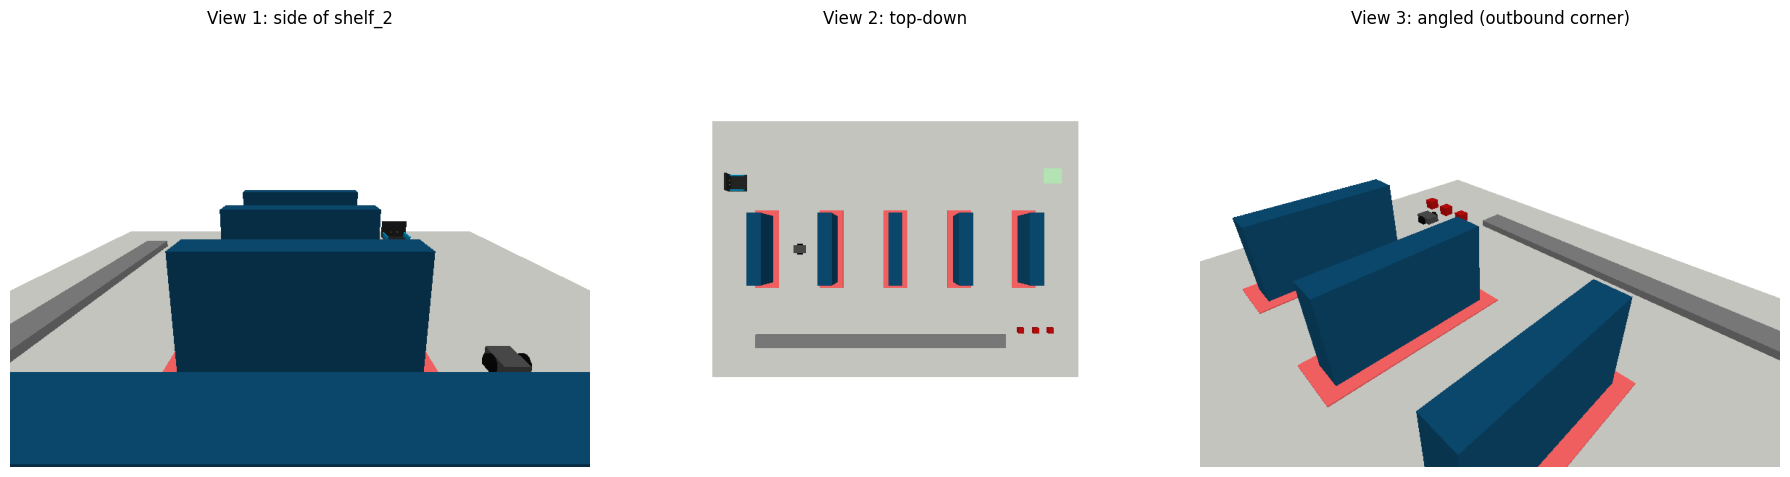

In [ ]:
fig, axes = plt.subplots(1, len(frames), figsize=(6 * len(frames), 5))
axes = np.atleast_1d(axes)
for ax, img, title in zip(axes, frames, titles):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.savefig("warehouse_views.png", dpi=150)
plt.show()